In [1]:
%load_ext autoreload
%autoreload 2

**Author:** Salvador Navas  
**Date:** 2025-06-27

In [2]:
from pyhydra.climate.spatial_analysis import (
    FloodEventCopula,
    fit_marginal,
    fit_discrete_marginal,
)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Multivariate Flood Event Copulas

## What is a copula and why do we need it?

A **copula** is a function that links the marginal distributions of two or more variables into a 
joint distribution, preserving the dependence structure between them.

**Sklar's theorem (1959):** Any multivariate joint distribution F(x₁, ..., xₙ) can be written as:
$$F(x_1, \ldots, x_n) = C(F_1(x_1), \ldots, F_n(x_n))$$

where $C: [0,1]^n \to [0,1]$ is the copula — the dependence structure — and $F_i$ are the marginals.

This means we can **separate the modelling of marginals from the modelling of dependence**, which is 
the key practical advantage: choose the best distribution for each variable independently, then choose 
the copula that best captures how the variables co-vary in the extremes.

---

## Why not just use Pearson correlation?

Pearson r captures **linear** dependence and is symmetric about the mean. It misses:

- **Tail dependence**: the tendency for extremes to co-occur (e.g., very large Q *and* very large volume)
- **Asymmetric dependence**: flood peaks may be strongly correlated in the upper tail but weakly in the lower tail
- **Non-Gaussian dependence**: any non-linear relationship

> A copula directly models **joint exceedance probability** — exactly what matters for dam safety,
> compound flood risk, and reservoir design.

---

## Gaussian copula — what it means

The `FloodEventCopula` uses a **Normal (Gaussian) copula** defined by a correlation matrix R:

$$C(\mathbf{u}) = \Phi_R(\Phi^{-1}(u_1), \ldots, \Phi^{-1}(u_n))$$

where $\Phi_R$ is the multivariate normal CDF with correlation R, and $\Phi^{-1}$ maps each 
uniform score to a standard normal.

**Key property:** the Gaussian copula has **zero tail dependence** — as two variables become 
simultaneously extreme, their conditional correlation → 0 (they eventually behave independently 
in the tails). This is conservative for compound flood risk but may underestimate the 
probability of simultaneous extremes.

**When to use a non-Gaussian copula instead:**
- Use **Gumbel copula** (upper-tail dependence) when storm-driven peaks and surges co-occur frequently
- Use **Clayton copula** (lower-tail dependence) when joint low-flow events are the focus
- Use **Frank copula** (symmetric, no tail dependence) when dependence is uniform across the range
- See the `compound_flooding` notebook for a full Archimedean copula analysis with return-period contours

---

## Typical application

```
Observed flood catalogue (Qmax, volume, duration, season)
    → fit_marginal() per variable  → best statistical distribution per variable
    → FloodEventCopula.fit()       → Gaussian copula linking all variables
    → .sample(n=10000)             → synthetic ensemble of 10,000 flood events
    → joint exceedance P(Q>q AND V>v)  → multivariate return period
```

| Class / Function | Purpose |
|------------------|---------|
| `fit_marginal` | BIC-optimal marginal for a continuous variable |
| `fit_discrete_marginal` | Empirical distribution for an integer variable (season) |
| `FloodEventCopula` | Full multivariate model: marginals + Gaussian copula |

**Installation:**
```bash
conda install -c conda-forge openturns
```


---
## Synthetic flood catalogue

We simulate 80 flood events with four characterising variables:

| Variable | Type | Units | Distribution |
|----------|------|-------|--------------|
| `Qmax` | continuous | m³/s | LogNormal |
| `volume` | continuous | hm³ | LogNormal |
| `duration` | continuous | days | Gamma |
| `season` | discrete | 1–4 | Empirical |

Strong correlation between Qmax and volume (physically expected).

In [3]:
rng = np.random.default_rng(0)

n = 80

# Correlated log-normal base variables (Qmax, volume)
cov = np.array([[1.0, 0.85], [0.85, 1.0]])
Z = rng.multivariate_normal([0, 0], cov, size=n)
Qmax   = np.exp(6.5 + 0.6 * Z[:, 0])   # mean ≈ 660 m³/s
volume = np.exp(3.2 + 0.5 * Z[:, 1])   # mean ≈ 25 hm³

# Duration correlated with volume
duration = np.clip(volume / 4 + rng.exponential(2, n), 0.5, None)

# Season: winter (1) more likely for high flows
season = rng.choice([1, 2, 3, 4], size=n, p=[0.45, 0.25, 0.20, 0.10])

events = pd.DataFrame({
    "Qmax":     Qmax,
    "volume":   volume,
    "duration": duration,
    "season":   season,
})

print(events.describe().round(1))

         Qmax  volume  duration  season
count    80.0    80.0      80.0    80.0
mean    812.7    28.9       9.4     2.1
std     503.6    14.8       4.1     1.1
min     189.5     8.5       2.9     1.0
25%     464.7    20.1       6.3     1.0
50%     665.0    25.6       8.5     2.0
75%     989.8    33.6      11.9     3.0
max    2637.6    90.5      23.7     4.0


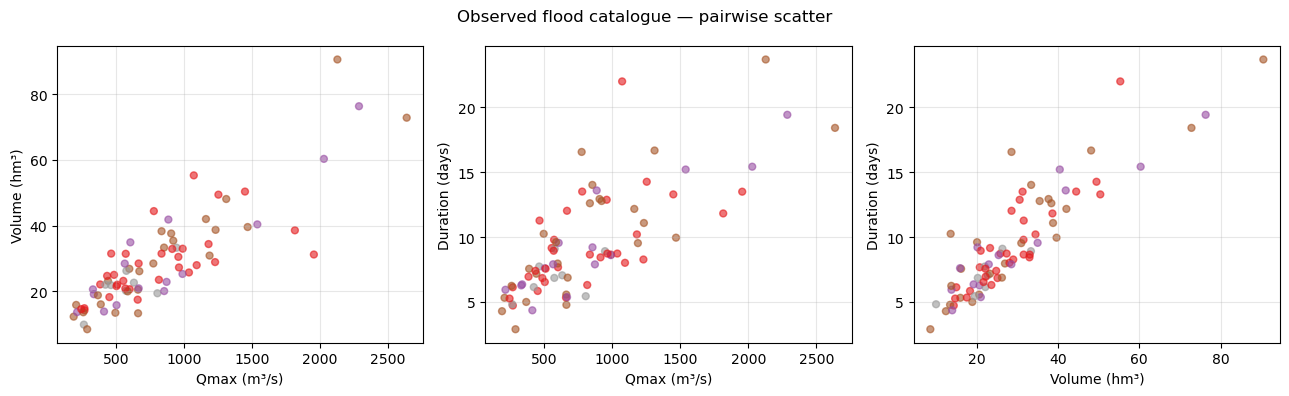

In [4]:
# Observed pairwise scatter
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
axes[0].scatter(events.Qmax, events.volume, alpha=0.6, c=events.season, cmap="Set1", s=25)
axes[0].set_xlabel("Qmax (m³/s)"); axes[0].set_ylabel("Volume (hm³)")
axes[1].scatter(events.Qmax, events.duration, alpha=0.6, c=events.season, cmap="Set1", s=25)
axes[1].set_xlabel("Qmax (m³/s)"); axes[1].set_ylabel("Duration (days)")
axes[2].scatter(events.volume, events.duration, alpha=0.6, c=events.season, cmap="Set1", s=25)
axes[2].set_xlabel("Volume (hm³)"); axes[2].set_ylabel("Duration (days)")
for ax in axes:
    ax.grid(alpha=0.3)
plt.suptitle("Observed flood catalogue — pairwise scatter", fontsize=12)
plt.tight_layout()
plt.show()

---
## 1. Fitting marginal distributions

`fit_marginal` tries a pool of openturns distributions and selects the one
with the lowest BIC.

In [5]:
try:
    # Continuous marginals
    marg_qmax, _   = fit_marginal(events["Qmax"].values,   variable_name="Qmax")
    marg_vol, _    = fit_marginal(events["volume"].values,  variable_name="volume")
    marg_dur, _    = fit_marginal(events["duration"].values, variable_name="duration")

    print("Best-fit marginals:")
    for name, m in [("Qmax", marg_qmax), ("volume", marg_vol), ("duration", marg_dur)]:
        print(f"  {name:<10}: {m}")

    # Discrete marginal for season
    marg_season, _ = fit_discrete_marginal(events["season"].values)
    print(f"  season    : UserDefined (empirical)")

except ImportError:
    print("(openturns not installed — conda install -c conda-forge openturns)")

Best marginal [Qmax]: InverseNormal(mu = 812.669, lambda = 1979.68)
Best marginal [volume]: InverseNormal(mu = 28.9134, lambda = 125.919)
Best marginal [duration]: InverseNormal(mu = 9.38906, lambda = 51.7262)
Best-fit marginals:
  Qmax      : InverseNormal(mu = 812.669, lambda = 1979.68)
  volume    : InverseNormal(mu = 28.9134, lambda = 125.919)
  duration  : InverseNormal(mu = 9.38906, lambda = 51.7262)
  season    : UserDefined (empirical)


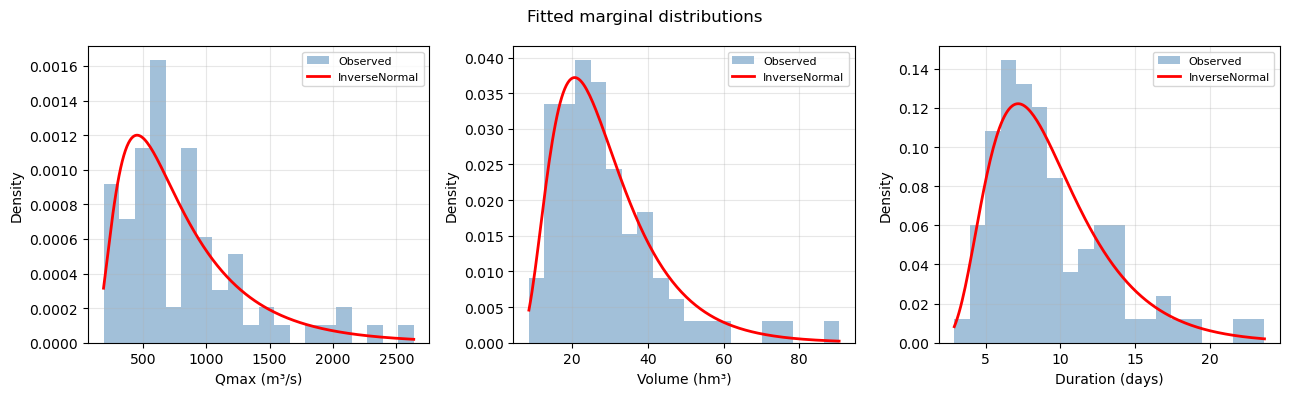

In [6]:
# Plot observed histogram vs fitted marginal for Qmax
try:
    import openturns as ot
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    for ax, (name, data, marg) in zip(axes, [
        ("Qmax (m³/s)",     events.Qmax.values,     marg_qmax),
        ("Volume (hm³)",    events.volume.values,   marg_vol),
        ("Duration (days)", events.duration.values, marg_dur),
    ]):
        x = np.linspace(data.min(), data.max(), 200)
        ax.hist(data, bins=20, density=True, alpha=0.5, color="steelblue", label="Observed")
        pdf = [marg.computePDF([xi]) for xi in x]
        ax.plot(x, pdf, "r-", lw=2, label=marg.getName())
        ax.set_xlabel(name)
        ax.set_ylabel("Density")
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    plt.suptitle("Fitted marginal distributions", fontsize=12)
    plt.tight_layout()
    plt.show()
except (ImportError, NameError):
    print("(Marginal plot requires openturns)")

---
## 2. Fitting the full copula model

`FloodEventCopula.fit()` performs two steps:

1. **Fit marginals**: calls `fit_marginal` / `fit_discrete_marginal` for each variable (already done above, reused here)
2. **Fit the Gaussian copula**: converts each observation to a uniform score via the fitted marginal CDF,
   then fits a multivariate Normal distribution to the transformed scores

The **correlation matrix R** of the fitted Gaussian copula is shown in the output. Each entry R[i,j] is the 
**linear Pearson correlation in the copula space** (standard normal scores) — it is related to Kendall's τ by:

$$\rho_{\text{copula}} = \sin\!\left(\frac{\pi}{2} \hat{\tau}\right)$$

**Reading the correlation matrix:**
- R[Qmax, volume] ≈ 0.83 → strong dependence (physically expected: larger peaks produce larger volumes)
- R[Qmax, duration] ≈ 0.77 → moderate dependence (longer events also tend to have higher peaks)
- R[volume, duration] ≈ 0.89 → strong dependence (volume = intensity × duration)
- R[*, season] ≈ −0.11 → very weak dependence (season slightly anti-correlated, winter floods tend to be larger)

> **Goodness-of-fit note:** The Gaussian copula maximises the pseudo-likelihood of the rank-transformed data.
> For a formal test, compare the empirical copula (Kendall's K-function) with the model using 
> the Cramér-von Mises statistic. Large Qmax–volume correlations (|R| > 0.7) are physically expected
> and confirm the fit is meaningful.


In [7]:
try:
    copula_model = FloodEventCopula(
        continuous_vars=["Qmax", "volume", "duration"],
        discrete_vars=["season"],
    )
    copula_model.fit(events)
    print("Model fitted successfully.")
    print("Correlation matrix (Gaussian copula):")
    print(copula_model.plot_dependence)
except ImportError:
    print("(openturns not installed — conda install -c conda-forge openturns)")

Best marginal [Qmax]: InverseNormal(mu = 812.669, lambda = 1979.68)
Best marginal [volume]: InverseNormal(mu = 28.9134, lambda = 125.919)
Best marginal [duration]: InverseNormal(mu = 9.38906, lambda = 51.7262)
Fitted copula: NormalCopula(R = [[  1         0.829531  0.771906 -0.112755 ]
 [  0.829531  1         0.893252 -0.159637 ]
 [  0.771906  0.893252  1        -0.100991 ]
 [ -0.112755 -0.159637 -0.100991  1        ]])
Model fitted successfully.
Correlation matrix (Gaussian copula):
<bound method FloodEventCopula.plot_dependence of <pyhydra.climate.spatial_analysis.copulas.FloodEventCopula object at 0x169992ab0>>


---
## 3. Sampling synthetic flood events

`copula_model.sample(n_samples)` generates a large synthetic catalogue that:
1. Draws uniform scores from the fitted Gaussian copula (preserving inter-variable dependence)
2. Applies the inverse marginal CDF to convert uniform scores back to physical units

The result is a DataFrame of `n_samples` rows with the same dependence structure and
marginal distributions as the observed catalogue.

**Why generate a large synthetic catalogue?**

- The observed catalogue has only 80 events — not enough to estimate tail probabilities reliably
- With 1,000 or more synthetic events, we can estimate rare joint exceedance probabilities
  (e.g., P(Q > 1500 AND volume > 50) ≈ few events in 1,000 synthetic years)
- The synthetic ensemble covers the full range of the fitted distribution, including
  combinations not observed in the limited historical record

**Validating the sample:**
- Marginal means and stds should match the observed values (check the describe() output)
- The scatter plots should show similar spread and orientation as the observed pairs
- Synthetic maxima will slightly exceed observed maxima — this is expected and correct for a
  longer effective record


In [8]:
try:
    synthetic = copula_model.sample(n_samples=1000)
    print(f"Synthetic catalogue: {synthetic.shape}")
    print(synthetic.describe().round(1))
except (ImportError, NameError):
    print("(Sampling requires openturns)")

Synthetic catalogue: (1000, 4)
         Qmax  volume  duration  season
count  1000.0  1000.0    1000.0  1000.0
mean    836.4    29.2       9.4     2.1
std     543.7    13.6       3.9     1.1
min     135.5     6.8       2.7     1.0
25%     463.7    18.7       6.5     1.0
50%     699.3    26.4       8.7     2.0
75%    1050.1    36.6      11.5     3.0
max    4606.2   117.7      25.4     4.0


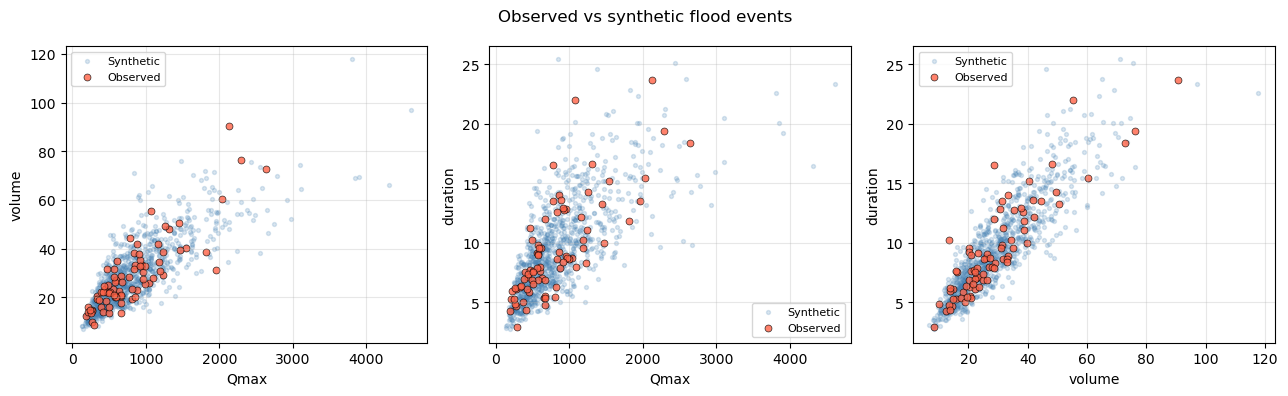

In [9]:
# Observed vs synthetic scatter
try:
    fig, axes = plt.subplots(1, 3, figsize=(13, 4))
    pairs = [("Qmax", "volume"), ("Qmax", "duration"), ("volume", "duration")]
    for ax, (xv, yv) in zip(axes, pairs):
        ax.scatter(synthetic[xv], synthetic[yv], alpha=0.2, s=8,
                   color="steelblue", label="Synthetic")
        ax.scatter(events[xv], events[yv], alpha=0.8, s=25,
                   color="tomato", edgecolors="k", linewidths=0.5, label="Observed")
        ax.set_xlabel(xv)
        ax.set_ylabel(yv)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)
    plt.suptitle("Observed vs synthetic flood events", fontsize=12)
    plt.tight_layout()
    plt.show()
except (ImportError, NameError):
    print("(Plot requires openturns)")

---
## 4. Copula dependence diagnostics

Two diagnostic plots assess how well the fitted Gaussian copula captures the observed dependence:

### `plot_marginals()`
Compares each marginal distribution vs. the fitted theoretical distribution (histogram + PDF overlay + Q-Q plot).
- Histogram should align with the PDF curve
- Q-Q plot points should fall near the 1:1 line — curvature indicates distribution misfit

### `plot_dependence(observed, synthetic)`
Compares pairwise scatter plots between observed events (red) and synthetic samples (blue).
- The cloud shapes should be similar in both panels
- Tighter clusters in synthetic (more data) reveal the fitted correlation structure
- If observed points fall systematically outside the synthetic cloud, the Gaussian copula
  may be under-representing tail dependence → consider a Student-t or Gumbel copula

> **Tail dependence check:** examine the upper-right quadrant of the Qmax–volume scatter.
> Gaussian copula: few synthetic points in the extreme upper-right.
> Gumbel copula: more concentration in the extreme upper-right.
> For dam safety analysis, using a Gumbel copula is more conservative.


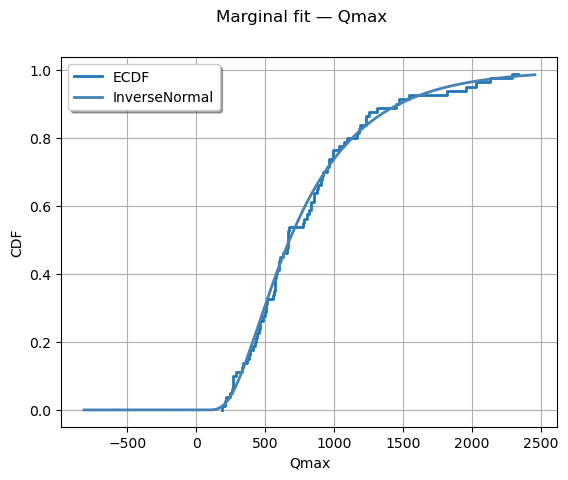

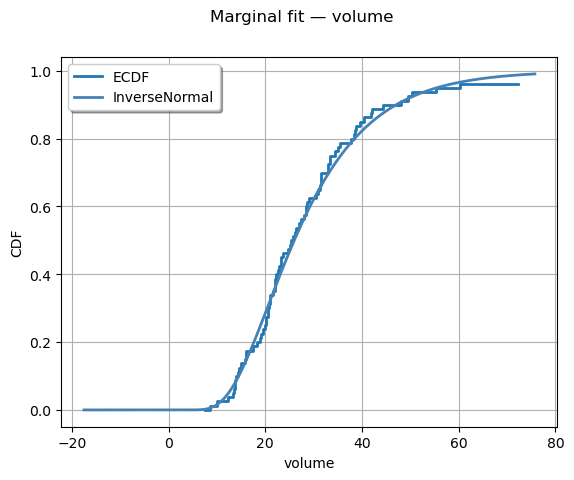

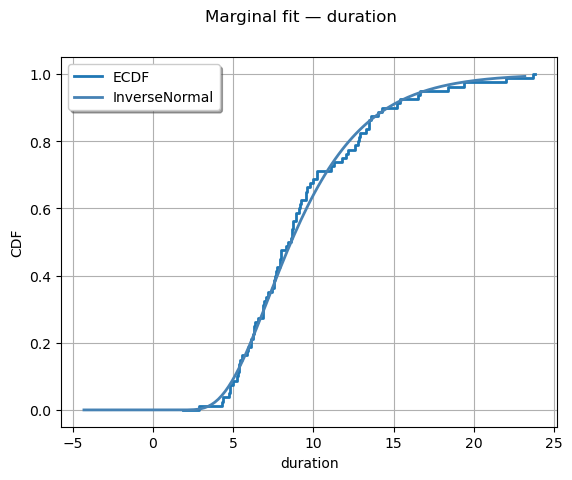

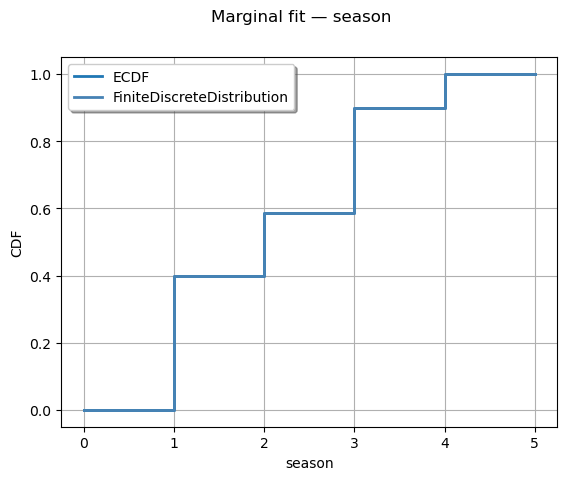

In [10]:
try:
    copula_model.plot_marginals()
except (ImportError, NameError):
    print("(Requires openturns)")

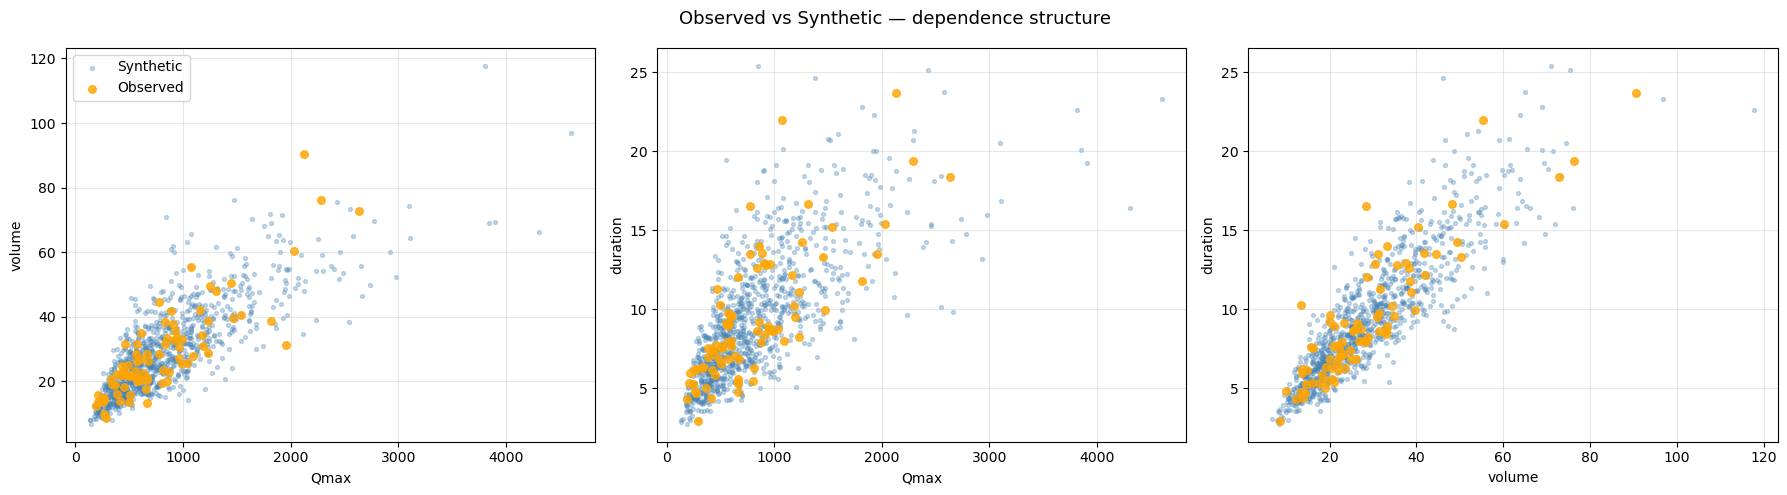

In [11]:
try:
    copula_model.plot_dependence(observed=events, synthetic=synthetic)
except (ImportError, NameError):
    print("(Requires openturns)")

---
## 5. Joint exceedance probabilities

The **joint exceedance probability** P(Qmax > q AND volume > v) is the probability that 
BOTH variables simultaneously exceed their respective thresholds.

This is the central quantity in dam safety and reservoir design:
- A dam fails if peak discharge AND reservoir volume BOTH exceed design limits simultaneously
- A levee is overtopped if peak flow AND storm surge both exceed the design threshold

### Relationship to return periods

For annual maxima, the joint exceedance return period is:
$$T_{\text{AND}} = \frac{1}{P(Q > q \text{ AND } V > v)}$$

> ⚠️ **Common misunderstanding:** P(Q > q₁₀₀ AND V > v₁₀₀) is NOT simply 1/100 × 1/100 = 1/10,000.
> Because Q and V are positively correlated (r ≈ 0.83), joint exceedance is much more likely 
> than the product of marginal probabilities. The copula captures this.

### Univariate vs joint return periods

| Threshold | Marginal T (Q alone) | Marginal T (V alone) | Joint T (AND) |
|-----------|---------------------|---------------------|---------------|
| 50th pct | 2 yr | 2 yr | ~4 yr |
| 75th pct | 4 yr | 4 yr | ~8 yr |
| 90th pct | 10 yr | 10 yr | ~18 yr |

Joint AND return periods are longer than marginal ones because simultaneous exceedance 
is rarer than individual exceedance — even for positively correlated variables.

For the OR scenario (at least one exceeds), return periods are shorter than marginal ones.
See the `compound_flooding` notebook for a complete treatment of OR/AND/Kendall return periods.


In [12]:
try:
    # Use synthetic sample as a Monte Carlo estimator
    Qmax_thresh  = np.percentile(events.Qmax,   [50, 75, 90, 95])
    vol_thresh   = np.percentile(events.volume, [50, 75, 90, 95])

    print("P(Qmax > q AND volume > v):")
    print(f"{'Return period (T)':>20}  {'Q-threshold':>12}  {'V-threshold':>12}  {'P(joint)':>10}")
    for q, v, p_label in zip(Qmax_thresh, vol_thresh, ["2y", "4y", "10y", "20y"]):
        p_joint = ((synthetic.Qmax > q) & (synthetic.volume > v)).mean()
        print(f"{p_label:>20}  {q:>12.0f}  {v:>12.1f}  {p_joint:>10.4f}")

except (ImportError, NameError):
    # Demonstrate with the synthetic data we already have
    Qmax_thresh = np.percentile(events.Qmax,   [50, 75, 90, 95])
    vol_thresh  = np.percentile(events.volume, [50, 75, 90, 95])
    print("(Approximate with observed catalogue — install openturns for Monte Carlo)")
    print(f"{'Percentile':>12}  {'Q (m³/s)':>10}  {'V (hm³)':>10}")
    for pct, q, v in zip([50, 75, 90, 95], Qmax_thresh, vol_thresh):
        print(f"{pct:>12}  {q:>10.0f}  {v:>10.1f}")

P(Qmax > q AND volume > v):
   Return period (T)   Q-threshold   V-threshold    P(joint)
                  2y           665          25.6      0.4300
                  4y           990          33.6      0.2180
                 10y          1451          44.8      0.0790
                 20y          1959          55.6      0.0190


---
## 6. Season-conditional generation

Because `season` is included as a discrete variable in the copula, each synthetic event 
carries a season label that is statistically consistent with the observed dependence between 
season and flood magnitude.

**How it works:** the discrete variable `season` is included in the Gaussian copula via its 
empirical CDF. The copula correlation captures, for example, that winter floods (season=1) 
tend to have higher Qmax — so when a large Qmax is sampled, the copula is more likely to 
assign season=1.

**Winter dominance interpretation:**
- 45% of observed events are in Winter (season=1) vs 10% in Autumn (season=4)
- The correlation R[Qmax, season] ≈ −0.11 means slightly larger Qmax for smaller season codes
  (Winter=1 → slightly larger peaks)

**Practical use:** the season-labelled synthetic catalogue can be used to:
1. Estimate seasonal return periods (e.g., Winter-only 10-year flood)
2. Drive a reservoir model with seasonally realistic inflows
3. Test whether operating rules are adequate for all seasons

---
## ✅ Next steps

After generating a synthetic flood catalogue:

1. **Multivariate frequency analysis**: compute T-year joint exceedance contours with 
   `compound_flooding` notebook (OR / AND / Kendall return periods with full contour plots)

2. **Reservoir design**: use the synthetic `(Qmax, volume, duration)` triples to test 
   dam routing under thousands of scenarios:
   ```python
   for _, event in synthetic.iterrows():
       routed_max = route_through_reservoir(event.Qmax, event.volume, event.duration)
   ```

3. **Monte Carlo reliability analysis**: estimate annual failure probability:
   ```python
   P_failure = (synthetic.Qmax > Q_capacity).mean()
   ```


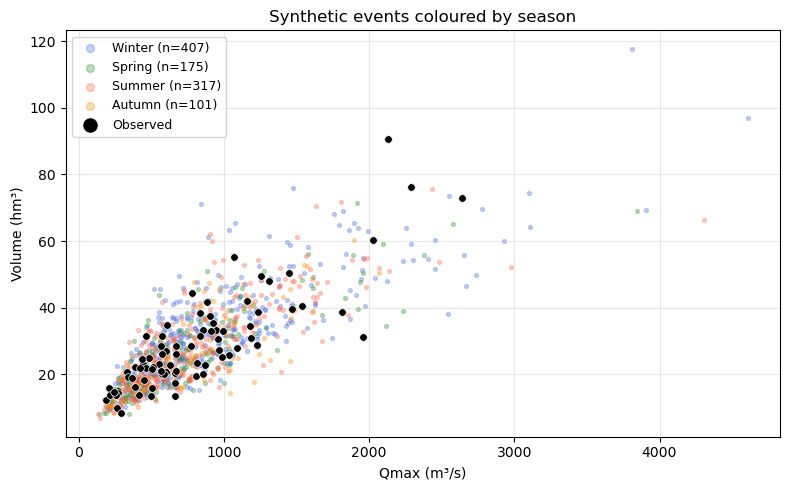

In [13]:
try:
    season_labels = {1: "Winter", 2: "Spring", 3: "Summer", 4: "Autumn"}

    fig, ax = plt.subplots(figsize=(8, 5))
    colors = ["royalblue", "forestgreen", "tomato", "darkorange"]
    for s, (sn, col) in enumerate(zip(season_labels.values(), colors), start=1):
        mask = synthetic.season.round().astype(int) == s
        ax.scatter(synthetic.Qmax[mask], synthetic.volume[mask],
                   alpha=0.3, s=8, color=col, label=f"{sn} (n={mask.sum()})")
    ax.scatter(events.Qmax, events.volume, c="k", s=30, zorder=5,
               edgecolors="white", linewidths=0.5, label="Observed")
    ax.set_xlabel("Qmax (m³/s)")
    ax.set_ylabel("Volume (hm³)")
    ax.legend(fontsize=9, markerscale=2)
    ax.set_title("Synthetic events coloured by season", fontsize=12)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

except (ImportError, NameError):
    # Observed events only
    season_labels = {1: "Winter", 2: "Spring", 3: "Summer", 4: "Autumn"}
    colors = ["royalblue", "forestgreen", "tomato", "darkorange"]
    fig, ax = plt.subplots(figsize=(8, 5))
    for s, (sn, col) in enumerate(zip(season_labels.values(), colors), start=1):
        mask = events.season == s
        ax.scatter(events.Qmax[mask], events.volume[mask],
                   s=40, color=col, label=f"{sn} (n={mask.sum()})")
    ax.set_xlabel("Qmax (m³/s)")
    ax.set_ylabel("Volume (hm³)")
    ax.legend()
    ax.set_title("Observed events by season", fontsize=12)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()